# 04-2 逻辑回归与 Softmax 回归：从二分类到多分类（代码 + 公式讲解）

> 上一讲把"预测连续值"讲清楚了；这一讲解决"**预测类别**"的问题，它的输出层与损失函数（Sigmoid / Softmax / 交叉熵）是后面所有神经网络的基础。

**本讲路线图：**
1. 为什么线性回归不能直接做分类？—— 先看一个"翻车"现场
2. Sigmoid：把任意实数"压"成 (0,1) 之间的概率
3. 逻辑回归模型与决策边界
4. 损失函数：从**极大似然**一步步推出**交叉熵**
5. 梯度与训练（手写实现，再和 sklearn 对照）
6. 多分类策略：OvO 与 OvR
7. **Softmax**：把"得分"变成"概率分布"
8. 交叉熵的**信息论**解释（熵 / KL 散度），标签平滑

**使用方式**：按顺序往下跑。每个公式后面基本都有一段代码把它"跑给你看"。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
np.set_printoptions(precision=4, suppress=True)

## 1 先看一个"翻车"现场：为什么不能直接用线性回归做分类

**问题**：某课程积累了历届学生的成绩，想根据"考试成绩 $x$（连续值）"预测"是否通过 $y\in\{1,0\}$（离散标签）"。

最省事的想法：还是用线性回归 $\hat y = wx+b$ 拟合 0/1 标签，然后"大于临界点算 1"。但它有两个致命问题：

1. **输出范围失控**：线性回归的输出是 $(-\infty,+\infty)$，而分类想要的是一个**概率**，必须落在 $(0,1)$ 之间。预测结果等于 10000 或者 −50 毫无意义。
2. **极易受异常值影响**：一旦混入一个极其巨大的异常样本，整条回归线会被严重拉偏，原本预测准确的普通样本反而被错误分类。

跑一下就能看到这两点：

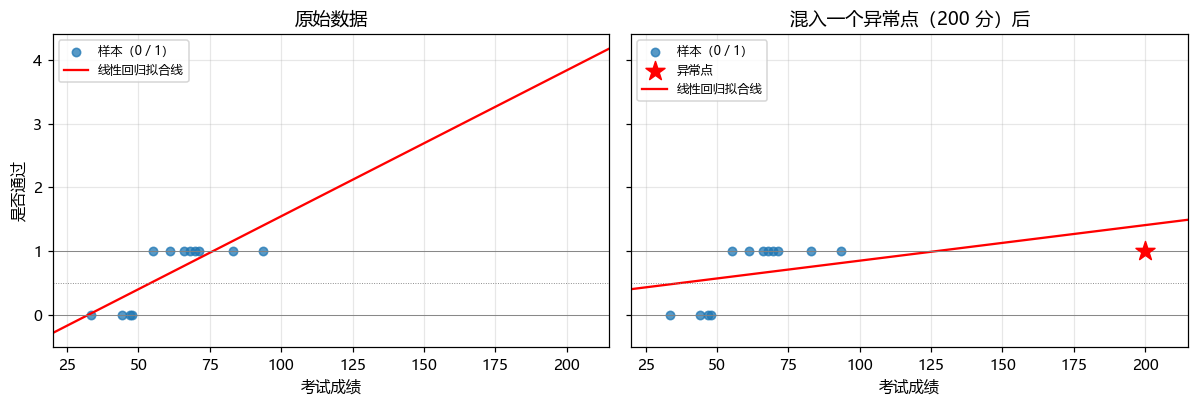

拟合线在 x=30 处的输出 = -0.06   ← 不在 [0,1] 内，根本不像"概率"
按"拟合值 > 0.5 即通过"分类：误分类数 0 → 3 个   ← 一个异常点制造了新的错误
"及格线"（拟合值=0.5 的位置）: 54.4 分 → 38.0 分   ← 整条线被严重拉偏


In [2]:
rng = np.random.default_rng(33)
n = 12
score = rng.uniform(30, 100, n)
# 真实世界：分数越高越容易通过（用逻辑函数生成"真实通过概率"）
prob = 1 / (1 + np.exp(-(score - 60) / 5))
passed = (rng.uniform(size=n) < prob).astype(int)

# ① 直接用线性回归拟合 0/1 标签
A = np.column_stack([score, np.ones(n)])
w_lin = np.linalg.lstsq(A, passed, rcond=None)[0]

# ② 再混入一个"极其巨大"的异常样本：成绩 200 分且通过
score2 = np.append(score, 200.0)
passed2 = np.append(passed, 1)
A2 = np.column_stack([score2, np.ones(len(score2))])
w_lin2 = np.linalg.lstsq(A2, passed2, rcond=None)[0]

xs = np.linspace(20, 215, 200)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), dpi=110, sharey=True)
for ax, wl, title in zip(axes, [w_lin, w_lin2], ['原始数据', '混入一个异常点（200 分）后']):
    ax.scatter(score, passed, s=30, alpha=0.75, label='样本（0 / 1）')
    if ax is axes[1]:
        ax.scatter([200], [1], color='red', marker='*', s=170, zorder=5, label='异常点')
    ax.plot(xs, wl[0]*xs + wl[1], 'r-', label='线性回归拟合线')
    ax.axhline(0, color='gray', lw=0.6); ax.axhline(1, color='gray', lw=0.6)
    ax.axhline(0.5, color='gray', lw=0.6, ls=':')
    ax.set_xlabel('考试成绩'); ax.set_xlim(20, 215)
    ax.set_title(title); ax.legend(loc='upper left', fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel('是否通过')
plt.tight_layout(); plt.show()

print(f'拟合线在 x=30 处的输出 = {w_lin[0]*30 + w_lin[1]:.2f}   ← 不在 [0,1] 内，根本不像"概率"')
x0a = (0.5 - w_lin[1]) / w_lin[0]
x0b = (0.5 - w_lin2[1]) / w_lin2[0]
err1 = int(((w_lin[0]*score + w_lin[1] > 0.5) != passed).sum())
err2 = int(((w_lin2[0]*score + w_lin2[1] > 0.5) != passed).sum())
print(f'按"拟合值 > 0.5 即通过"分类：误分类数 {err1} → {err2} 个   ← 一个异常点制造了新的错误')
print(f'"及格线"（拟合值=0.5 的位置）: {x0a:.1f} 分 → {x0b:.1f} 分   ← 整条线被严重拉偏')

**解决方案**：给线性回归的输出**叠加一个"变形器"**，把 $(-\infty,+\infty)$ 压到 $(0,1)$ —— 这就是**逻辑回归**。

## 2 Sigmoid 函数：把实数"压"成概率

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

它有几个要记住的性质：
- **值域 $(0,1)$**，正好可以当概率用；$z\to+\infty$ 时趋近 1，$z\to-\infty$ 时趋近 0；
- $\sigma(0)=0.5$，是"正负类"的分界线；
- 单调递增，**不改变大小关系**；
- 导数很漂亮：$\sigma'(z)=\sigma(z)\bigl(1-\sigma(z)\bigr)$，最大值只有 0.25（这个 0.25 就是后面"梯度消失"话题的起点）。

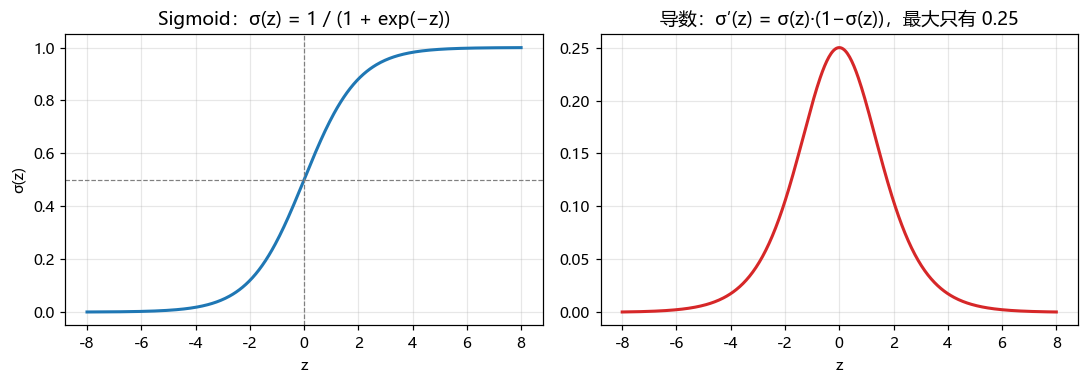

σ(0) = 0.5    σ(2) = 0.881    σ(−2) = 0.119


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 400)
sig = sigmoid(z)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), dpi=110)
axes[0].plot(z, sig, lw=2)
axes[0].axhline(0.5, color='gray', ls='--', lw=0.8)
axes[0].axvline(0, color='gray', ls='--', lw=0.8)
axes[0].set_title('Sigmoid：σ(z) = 1 / (1 + exp(−z))')
axes[0].set_xlabel('z'); axes[0].set_ylabel('σ(z)'); axes[0].grid(alpha=0.3)

axes[1].plot(z, sig * (1 - sig), lw=2, color='#d62728')
axes[1].set_title('导数：σ′(z) = σ(z)·(1−σ(z))，最大只有 0.25')
axes[1].set_xlabel('z'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('σ(0) =', round(float(sigmoid(0)), 3), '   σ(2) =', round(float(sigmoid(2)), 3), '   σ(−2) =', round(float(sigmoid(-2)), 3))

## 3 逻辑回归模型与决策边界

**逻辑回归 = 线性回归 + Sigmoid 概率映射**：

$$z = \boldsymbol w^{\mathrm T}\boldsymbol x + b,\qquad \hat y = \sigma(z) = P(y=1\mid \boldsymbol x)$$

- 前半段 $z$ 是"打分"（线性回归干的事）；
- Sigmoid 把分数转成概率（模型输出）。

**判决规则**：$z>0 \Leftrightarrow \hat y > 0.5$ → 判为正类；$z<0 \Leftrightarrow \hat y < 0.5$ → 判为负类；$z=0$ 时 $\hat y=0.5$ 是临界。

注意 $z = \boldsymbol w^{\mathrm T}\boldsymbol x+b=0$ 是一条**直线**（高维时是超平面）—— 它就是**决策边界**。

**换个视角看它"逻辑"在哪**：把式子反解一下

$$\log\frac{\hat y}{1-\hat y} = \boldsymbol w^{\mathrm T}\boldsymbol x \qquad\left(\text{左边叫"对数几率" log-odds}\right)$$

也就是说：**逻辑回归用线性模型去预测"对数几率"**，再通过逻辑函数转回概率。这也是它名字的由来，属于"广义线性回归"的特例（周志华《机器学习》P58）。

**判别式模型**：逻辑回归直接对 $P(y\mid\boldsymbol x)$ 建模，**不需要假设数据分布**，避免分布假设不准确带来的问题；而且它不仅给出类别，还能给出概率近似（后面调阈值很方便）。

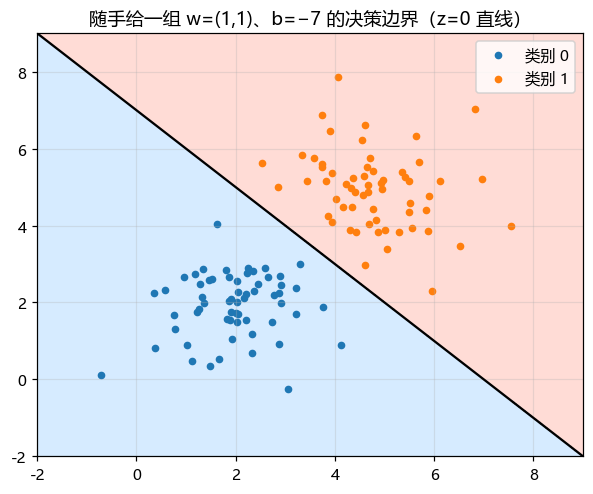

In [4]:
rng = np.random.default_rng(1)
n = 120
X0 = rng.normal([2, 2], 1.0, (n // 2, 2))    # 类别 0：左下
X1 = rng.normal([5, 5], 1.0, (n // 2, 2))    # 类别 1：右上
X = np.vstack([X0, X1])
t = np.r_[np.zeros(n // 2), np.ones(n // 2)]

def plot_boundary(w, b, title=''):
    # 在网格上计算概率，画出 p = 0.5 的决策边界
    gx, gy = np.meshgrid(np.linspace(-2, 9, 300), np.linspace(-2, 9, 300))
    P = sigmoid(w[0]*gx + w[1]*gy + b)
    plt.contourf(gx, gy, P, levels=[0, 0.5, 1], colors=['#cfe8ff', '#ffd6cf'], alpha=0.85)
    plt.contour(gx, gy, P, levels=[0.5], colors='k', linewidths=1.5)
    plt.scatter(X[t == 0, 0], X[t == 0, 1], s=16, label='类别 0')
    plt.scatter(X[t == 1, 0], X[t == 1, 1], s=16, label='类别 1')
    plt.title(title); plt.legend(); plt.grid(alpha=0.3)

plt.figure(figsize=(5.5, 4.6), dpi=110)
plot_boundary(np.array([1.0, 1.0]), -7.0, '随手给一组 w=(1,1)、b=−7 的决策边界（z=0 直线）')
plt.tight_layout(); plt.show()

## 4 损失函数：从极大似然推导交叉熵

模型有了，怎么定"好不好"？分类问题里均方差 MSE 不好用（Sigmoid + MSE 的损失曲面非凸、梯度也容易消失），正确做法是从**概率**出发。

**Step 1：写出似然。** 模型说"样本为正类的概率是 $p$"，把标签 $y\in\{0,1\}$ 用一个式子装下：

$$P(y\mid \boldsymbol x) = p^{\,y}\,(1-p)^{\,1-y}$$

（检验一下：$y=1$ 时为 $p$；$y=0$ 时为 $1-p$。✓）

**Step 2：假设样本独立同分布**，整批数据的似然是连乘：

$$L(\boldsymbol w) = \prod_{n=1}^{N} p_n^{\,y_n}\,(1-p_n)^{\,1-y_n}$$

**Step 3：取对数（把连乘变连加）并改成"最小化负对数似然"**：

$$\min_{\boldsymbol w}\ \Bigl[-\log L(\boldsymbol w)\Bigr] = \min_{\boldsymbol w}\ -\sum_{n=1}^{N}\Bigl[y_n\log p_n + (1-y_n)\log(1-p_n)\Bigr]$$

这个式子就是**二分类交叉熵损失（cross-entropy）**。

**直觉**：交叉熵只惩罚"真实类别的预测概率"。预测概率离 1 越远，$-\log p$ 越大、惩罚越狠（下图）；而且它"没有上限"——错得越离谱，梯度越强，这是 MSE 做不到的。

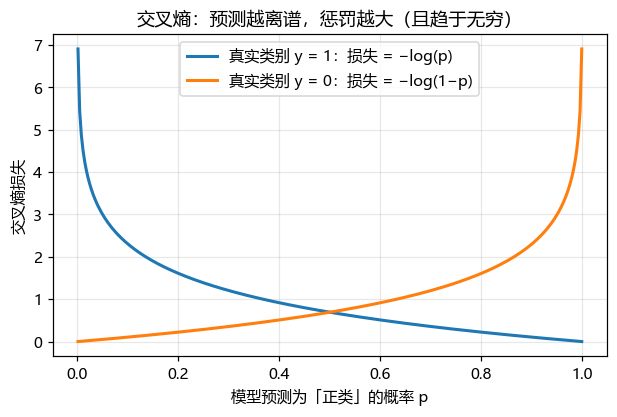

In [5]:
p = np.linspace(0.001, 0.999, 300)
plt.figure(figsize=(6.5, 3.8), dpi=110)
plt.plot(p, -np.log(p), lw=2, label='真实类别 y = 1：损失 = −log(p)')
plt.plot(p, -np.log(1 - p), lw=2, label='真实类别 y = 0：损失 = −log(1−p)')
plt.xlabel('模型预测为「正类」的概率 p'); plt.ylabel('交叉熵损失')
plt.title('交叉熵：预测越离谱，惩罚越大（且趋于无穷）')
plt.legend(); plt.grid(alpha=0.3); plt.show()

### 梯度长什么样？

对损失求导（中间会用到 $\sigma'(z)=\sigma(1-\sigma)$，**Sigmoid 的导数恰好把链式法则里的分母约掉**，所以结果非常干净）：

$$\frac{\partial L}{\partial \boldsymbol w} = \frac{1}{N}\sum_{n=1}^{N}\bigl(p_n - y_n\bigr)\boldsymbol x_n = -\frac{1}{N}\sum_{n=1}^{N}\bigl(y_n - p_n\bigr)\boldsymbol x_n$$

记法："**（预测概率 − 真实标签）× 特征**"。迭代更新依然是熟悉的梯度下降：

$$\boldsymbol w \leftarrow \boldsymbol w - \eta\frac{\partial L}{\partial \boldsymbol w}$$

> 剧透：Softmax 回归（多分类）的梯度是同一个形式 —— "**预测概率 − 真实标签**"。这不是巧合，是所有"指数族 + 极大似然"模型的共性。

### 手写训练一遍

学到的参数: w = [1.578 1.687]  b = -10.913
训练集准确率: 1.0


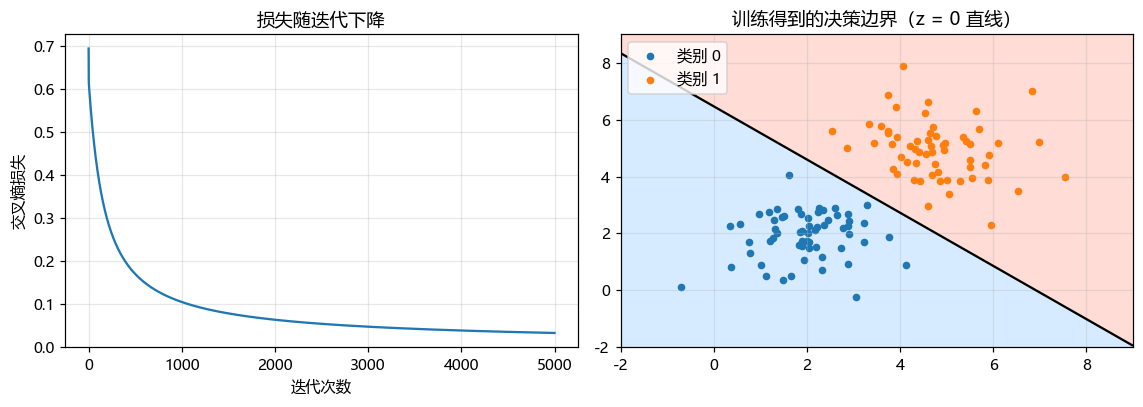

In [6]:
def cross_entropy(w, b, X, t):
    p = sigmoid(X @ w + b)
    return float(-np.mean(t*np.log(p) + (1 - t)*np.log(1 - p)))

w = np.zeros(2); b = 0.0
eta = 0.1
hist = [cross_entropy(w, b, X, t)]
for it in range(5000):
    p = sigmoid(X @ w + b)
    gw = X.T @ (p - t) / len(t)      # ∂L/∂w = (1/N)·Xᵀ(p − t)
    gb = float((p - t).mean())
    w = w - eta * gw
    b = b - eta * gb
    hist.append(cross_entropy(w, b, X, t))

print('学到的参数: w =', np.round(w, 3), ' b =', round(b, 3))
print('训练集准确率:', round(float(((sigmoid(X @ w + b) > 0.5) == t).mean()), 3))

fig = plt.figure(figsize=(10.5, 3.8), dpi=110)
ax1 = plt.subplot(1, 2, 1)
ax1.plot(hist); ax1.set_xlabel('迭代次数'); ax1.set_ylabel('交叉熵损失')
ax1.set_title('损失随迭代下降'); ax1.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plot_boundary(w, b, '训练得到的决策边界（z = 0 直线）')
plt.tight_layout(); plt.show()

In [7]:
# 和 sklearn 对照一下
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression().fit(X, t)
print('sklearn:  w =', np.round(clf.coef_[0], 3), ' b =', round(float(clf.intercept_[0]), 3))
print('手写的:   w =', np.round(w, 3), ' b =', round(b, 3))
print('（sklearn 默认带 L2 正则，两者不会完全相同，方向一致即可）')

sklearn:  w = [1.845 1.894]  b = -12.795
手写的:   w = [1.578 1.687]  b = -10.913
（sklearn 默认带 L2 正则，两者不会完全相同，方向一致即可）


## 5 多分类怎么办？OvO 与 OvR / OvR 用几个二分类器拼出来

真实任务很多是**多分类**：手写数字 10 类、ImageNet 1000 类。逻辑回归只会二分类，怎么扩展？

- **一对一（OvO，One vs One）**：任意两个类别之间训练一个分类器，共需 $C(C-1)/2$ 个。4 类 → 6 个分类器。预测时让它们"投票"。
- **一对其余（OvR，One vs Rest）**：每个类别 vs "其余所有类别"训练一个分类器，共需 $C$ 个。预测时取**输出概率最大**的那个类别：$c^* = \arg\max_c f_c(\boldsymbol x)$。

下面用 OvR 演示：3 个类别 → 3 个二分类器 → argmax 决策。

前 3 个样本的各类概率（列 = 类别 0/1/2）:
[[0.996 0.008 0.001]
 [1.    0.032 0.   ]
 [0.147 0.042 0.094]]
argmax 预测: [0 0 0 0 0 0 0 0 0 0] ，真实标签: [0 0 0 0 0 0 0 0 0 0]


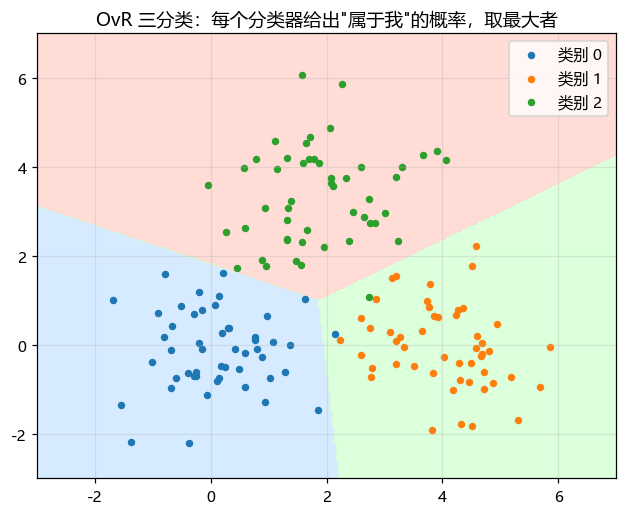

In [8]:
rng = np.random.default_rng(2)
centers = np.array([[0, 0], [4, 0], [2, 3.5]])
Xm = np.vstack([rng.normal(c, 0.9, (50, 2)) for c in centers])
ym = np.repeat([0, 1, 2], 50)

def train_binary(X, t, eta=0.1, iters=3000):
    w = np.zeros(X.shape[1]); b = 0.0
    for _ in range(iters):
        p = sigmoid(X @ w + b)
        w = w - eta * (X.T @ (p - t)) / len(t)
        b = b - eta * float((p - t).mean())
    return w, b

# 3 个"我 vs 其余"的分类器
models = [train_binary(Xm, (ym == c).astype(float)) for c in range(3)]

def ovr_proba(X):
    return np.column_stack([sigmoid(X @ w + b) for w, b in models])

proba = ovr_proba(Xm)
print('前 3 个样本的各类概率（列 = 类别 0/1/2）:')
print(np.round(proba[:3], 3))
print('argmax 预测:', proba.argmax(1)[:10], '，真实标签:', ym[:10])

gx, gy = np.meshgrid(np.linspace(-3, 7, 300), np.linspace(-3, 7, 300))
grid = np.column_stack([gx.ravel(), gy.ravel()])
Z = ovr_proba(grid).argmax(1).reshape(gx.shape)

plt.figure(figsize=(5.8, 4.8), dpi=110)
plt.contourf(gx, gy, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=['#cfe8ff', '#d6ffd6', '#ffd6cf'], alpha=0.85)
for c in range(3):
    plt.scatter(Xm[ym == c, 0], Xm[ym == c, 1], s=15, label=f'类别 {c}')
plt.legend(); plt.title('OvR 三分类：每个分类器给出"属于我"的概率，取最大者')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

> OvR 的缺点：每个分类器都在解决一个"不平衡"问题（比如 3 类时，正负样本是 1:2），而且各分类器的概率尺度不完全可比。所以就有了更"原生"的多分类方案 —— **Softmax 回归**（下一节）。它也是神经网络做分类时的标准输出层。

## 6 One-Hot 编码：把类别变成向量

神经网络/矩阵运算的世界里，标签也得是**向量**。最常用的表示：类别 $c$ → 一个只有第 $c$ 位是 1 的向量。

$$\text{类别 }3 \;\longrightarrow\; (0,0,1,0,0)^{\mathrm T}$$

In [9]:
def one_hot(y, C):
    Y = np.zeros((len(y), C))
    Y[np.arange(len(y)), y] = 1
    return Y

Y = one_hot(ym, 3)
print('前 5 个标签:', ym[:5])
print('对应的 one-hot 编码:')
print(Y[:5])

前 5 个标签: [0 0 0 0 0]
对应的 one-hot 编码:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


## 7 Softmax：把"得分"变成"概率分布"

先看问题：多分类时，我们给每个类别算一个线性得分

$$z_c = \boldsymbol w_c^{\mathrm T}\boldsymbol x,\qquad \boldsymbol z = \boldsymbol W\boldsymbol x \in \mathbb R^{C}$$

$\arg\max_c z_c$ 已经能"选类别"了，但这些得分**不是概率**：可能有负数、加起来也不等于 1。例如

$$\boldsymbol z = [3.2,\ 1.5,\ -0.7],\qquad \textstyle\sum_c z_c \neq 1,\quad z_3<0$$

需要一个映射，把任意实数得分变成"合法的概率分布"。**Softmax** 就是干这个的：

$$\hat y_c = p^c(\boldsymbol x;\boldsymbol w_c) = \frac{\exp(z_c)}{\sum_{k=1}^{C}\exp(z_k)}$$

它做了两件事：**指数拉伸 + 归一化**。
- 每个数先取指数（保证为正），再除以总和（保证加起来是 1）；
- 指数是单调的，所以 **Softmax 不改变类别排序**，只是把得分翻译成"可解释的概率"；
- 指数会放大差距（"马太效应"）：得分稍高的类别，概率被抬得更明显。

In [10]:
def softmax(z):
    z = np.asarray(z, dtype=float)
    z = z - z.max()              # 数值稳定的关键一步，见下一个 cell
    e = np.exp(z)
    return e / e.sum()

z = np.array([3.2, 1.5, -0.7])
print('原始得分 z =', z, '  求和 =', round(float(z.sum()), 2), '  有负数吗？', bool((z < 0).any()))
p = softmax(z)
print('softmax 之后 =', np.round(p, 3), '  求和 =', round(float(p.sum()), 6))
print('类别排序变了吗？', list(np.argsort(z)) == list(np.argsort(p)))

原始得分 z = [ 3.2  1.5 -0.7]   求和 = 4.0   有负数吗？ True
softmax 之后 = [0.831 0.152 0.017]   求和 = 1.0
类别排序变了吗？ True


In [11]:
# 为什么要"先减去最大值"：防止 exp 溢出
with np.errstate(over='ignore'):
    raw = np.exp([1000., 1001.])
print('直接 exp 大分数:', raw, ' ← inf，程序就废了')
print('减去最大值后再算:', np.round(softmax([1000., 1001.]), 3), ' ← 结果正确且不溢出')
print('（减去同一个常数，分子分母同时乘 e^{-max}，结果不变——数学上等价）')
print()
print('马太效应：得分差距越大，概率被放大得越极端')
for zz in [np.array([1.0, 0.5, 0.0]), np.array([2.0, 1.0, 0.0])]:
    print('  z =', zz, '→ p =', np.round(softmax(zz), 3))

直接 exp 大分数: [inf inf]  ← inf，程序就废了
减去最大值后再算: [0.269 0.731]  ← 结果正确且不溢出
（减去同一个常数，分子分母同时乘 e^{-max}，结果不变——数学上等价）

马太效应：得分差距越大，概率被放大得越极端
  z = [1.  0.5 0. ] → p = [0.506 0.307 0.186]
  z = [2. 1. 0.] → p = [0.665 0.245 0.09 ]


## 8 Softmax 回归的损失与梯度

有了概率分布，损失函数仍然是**交叉熵**（推广到多类）：

$$L(\boldsymbol W) = -\frac{1}{N}\sum_{n=1}^{N}\sum_{c=1}^{C} y_{nc}\log \hat y_{nc}$$

配合 one-hot 标签，每个样本求和里**实际只剩一项**：$L = -\log \hat y_{c^*}$（$c^*$ 是真实类别）——"**真实类别的预测概率越高，损失越小**"：

- 模型 A：$\hat{\boldsymbol y} = (0.03,0.05,\mathbf{0.90},0.02)$，CE $=-\log 0.90 \approx 0.105$
- 模型 B：$\hat{\boldsymbol y} = (0.20,0.30,\mathbf{0.10},0.40)$，CE $=-\log 0.10 \approx 2.303$

**信息论视角**（这就是"交叉熵"名字的来源）：

| 概念 | 公式 | 含义 |
|---|---|---|
| 信息量 | $I(x)=-\log p(x)$ | 概率越小的事件，发生了包含的信息越多 |
| 香农熵 | $H(p)=-\sum_c p_c\log p_c$ | 分布自身的"不确定度" |
| 交叉熵 | $H(p,q)=-\sum_c p_c\log q_c$ | 用分布 $q$ 去编码真实分布 $p$ 的代价 |
| KL 散度 | $D_{KL}(p\|q)=\sum_c p_c\log\frac{p_c}{q_c}$ | 两个分布的"距离" |

它们之间有一个漂亮的关系：$D_{KL}(p\|q)=H(p,q)-H(p)$。真实标签 $p$ 是固定的（one-hot），所以 $H(p)$ 是常数 —— **最小化交叉熵 $\Leftrightarrow$ 最小化 KL 散度**，也就是"让预测分布尽量逼近真实分布"。

**梯度**（对 $\boldsymbol W$ 求导，链式法则分三步：$\partial z/\partial W = \boldsymbol x$，$\partial L/\partial \hat y = -y/\hat y$，$\partial \hat y/\partial z = \hat y(1-\hat y)$ 或 $-\hat y_c\hat y_j$），最终结果出奇地简洁：

$$\frac{\partial L}{\partial \boldsymbol W} = \frac{1}{N}\boldsymbol X^{\mathrm T}\bigl(\hat{\boldsymbol Y}-\boldsymbol Y\bigr) \qquad\text{即：}\quad \text{「预测概率} - \text{真实标签」}$$

跟二分类逻辑回归一模一样！所以下面训练代码和前面几乎一样，只是 Sigmoid 换成 Softmax、标量换成矩阵。

In [12]:
# 交叉熵数值验证（对应上面模型 A / 模型 B 的例子）
def ce_loss(y_true, y_pred):
    return float(-np.sum(y_true * np.log(y_pred)))

y_true = np.array([0, 0, 1, 0.])       # 真实类别是第 3 类
A = np.array([0.03, 0.05, 0.90, 0.02])
B = np.array([0.20, 0.30, 0.10, 0.40])
print('模型 A（很自信且猜对了）CE =', round(ce_loss(y_true, A), 3), ' = −log 0.90')
print('模型 B（把真实类别猜成 0.10）CE =', round(ce_loss(y_true, B), 3), ' = −log 0.10')

模型 A（很自信且猜对了）CE = 0.105  = −log 0.90
模型 B（把真实类别猜成 0.10）CE = 2.303  = −log 0.10


In [13]:
# 信息论关系验证：D_KL = 交叉熵 − 熵
def entropy(p):      return float(-np.sum(p[p > 0] * np.log(p[p > 0])))
def cross_ent(p, q): return float(-np.sum(p[p > 0] * np.log(q[p > 0])))
def kl_div(p, q):    return float(np.sum(p[p > 0] * np.log(p[p > 0] / q[p > 0])))

p = np.array([0, 0, 1, 0.])             # 真实分布（one-hot）
q = np.array([0.03, 0.05, 0.90, 0.02])  # 预测分布
print('真实分布的熵  H(p)     =', round(abs(entropy(p)), 4), '  （one-hot 的熵恒为 0）')
print('交叉熵        H(p, q)  =', round(cross_ent(p, q), 4))
print('KL 散度       D_KL     =', round(kl_div(p, q), 4))
print('H(p,q) − H(p)          =', round(cross_ent(p, q) - entropy(p), 4), ' ← 与 KL 相等')

真实分布的熵  H(p)     = 0.0   （one-hot 的熵恒为 0）
交叉熵        H(p, q)  = 0.1054
KL 散度       D_KL     = 0.1054
H(p,q) − H(p)          = 0.1054  ← 与 KL 相等


## 9 完整训练一个 Softmax 回归（三分类）

整体流程（后面神经网络也是这个套路，只是把 $z=\boldsymbol W\boldsymbol x$ 换成更复杂的网络）：

$$\underbrace{\boldsymbol z = \boldsymbol W\boldsymbol x}_{\text{全连接层}} \;\to\; \underbrace{\hat{\boldsymbol y}=\text{softmax}(\boldsymbol z)}_{\text{激活函数}} \;\to\; \underbrace{L = -\sum_c y_c\log\hat y_c}_{\text{交叉熵损失}} \;\to\; \boldsymbol W \leftarrow \boldsymbol W - \eta\frac{\partial L}{\partial \boldsymbol W}$$

训练完成：最终损失 = 0.0411 ，训练集准确率 = 0.987


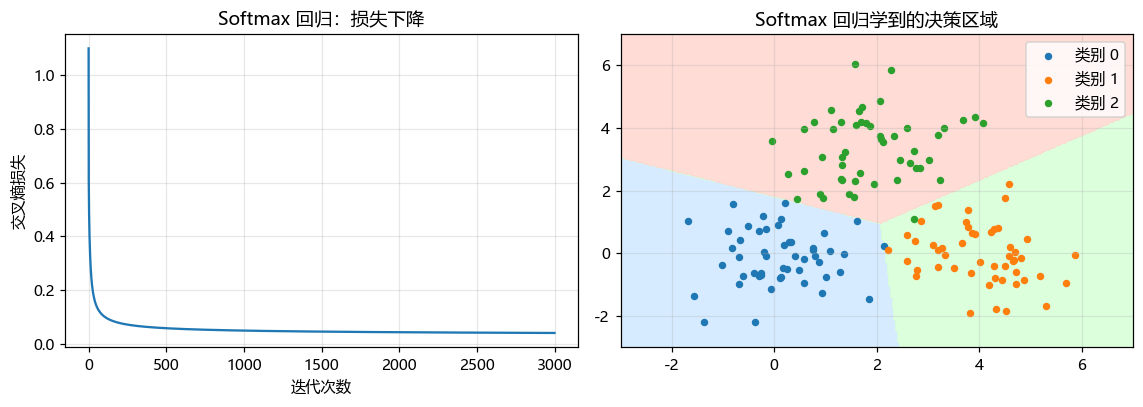

In [14]:
def softmax_rows(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def train_softmax(X, Y, eta=0.5, iters=3000):
    N, D = X.shape
    C = Y.shape[1]
    Xb = np.column_stack([X, np.ones(N)])          # 加一列 1（偏置）
    W = np.zeros((D + 1, C))
    hist = []
    for it in range(iters):
        P = softmax_rows(Xb @ W)
        hist.append(float(-np.mean(np.sum(Y * np.log(P + 1e-12), axis=1))))
        G = Xb.T @ (P - Y) / N                     # 梯度 = (1/N)·Xᵀ(预测 − 真实)
        W = W - eta * G
    return W, hist

W, hist = train_softmax(Xm, Y)
Xb = np.column_stack([Xm, np.ones(len(Xm))])
pred = softmax_rows(Xb @ W).argmax(1)
print('训练完成：最终损失 =', round(hist[-1], 4), '，训练集准确率 =', round(float((pred == ym).mean()), 3))

fig = plt.figure(figsize=(10.5, 3.8), dpi=110)
ax1 = plt.subplot(1, 2, 1); ax1.plot(hist)
ax1.set_xlabel('迭代次数'); ax1.set_ylabel('交叉熵损失')
ax1.set_title('Softmax 回归：损失下降'); ax1.grid(alpha=0.3)
ax2 = plt.subplot(1, 2, 2)
gx, gy = np.meshgrid(np.linspace(-3, 7, 300), np.linspace(-3, 7, 300))
grid = np.column_stack([gx.ravel(), gy.ravel(), np.ones(gx.size)])
Zc = softmax_rows(grid @ W).argmax(1).reshape(gx.shape)
ax2.contourf(gx, gy, Zc, levels=[-0.5, 0.5, 1.5, 2.5], colors=['#cfe8ff', '#d6ffd6', '#ffd6cf'], alpha=0.85)
for c in range(3):
    ax2.scatter(Xm[ym == c, 0], Xm[ym == c, 1], s=15, label=f'类别 {c}')
ax2.legend(); ax2.set_title('Softmax 回归学到的决策区域'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
# 和 sklearn 对照
clf2 = LogisticRegression(max_iter=2000).fit(Xm, ym)
print(f'手写 Softmax 回归   训练准确率: {(pred == ym).mean():.3f}')
print(f'sklearn 多分类逻辑回归 训练准确率: {(clf2.predict(Xm) == ym).mean():.3f}')

手写 Softmax 回归   训练准确率: 0.987
sklearn 多分类逻辑回归 训练准确率: 0.987


## 10 标签平滑（Label Smoothing）

一个容易忽略的细节：one-hot 是"**硬标签**"，它告诉模型"真实类别概率就应该是 1，其他必须是 0"。

模型为了逼近 1，会把得分越推越大（$\log$ 在接近 1 处导数爆炸），结果**过度自信**、泛化变差。

**标签平滑**把少量概率 $\alpha$ "匀给"所有类别（原论文 Szegedy 等 2016 的写法，把均匀分布混进来）：

$$y^{LS} = (1-\alpha)\,y + \frac{\alpha}{C}\mathbf 1 \qquad\Longrightarrow\qquad
\begin{cases}1-\alpha+\frac{\alpha}{C}, & i=c\\[2pt] \dfrac{\alpha}{C}, & i\neq c\end{cases}$$

例如 $C=4,\ \alpha=0.1$ 时：$(0,0,\mathbf 1,0)\to(0.025,0.025,\mathbf{0.925},0.025)$。目的：**缓解过拟合**（不让模型对"绝对正确"过度自信）。

> 课件里还有一种写法：$y_c^{LS}=1-\alpha$、其余每个 $=\alpha/(C-1)$。两种写法**只是 $\alpha$ 的参数约定不同**（同取 $\alpha=0.1$ 时分别是 0.925 和 0.9，两种理解都对），作用完全一样。

In [16]:
def label_smoothing_A(y, C, alpha=0.1):
    # 原论文写法：(1−α)·one-hot + α/C
    return (1 - alpha) * one_hot(y, C) + alpha / C

def label_smoothing_B(y, C, alpha=0.1):
    # 另一种写法：真实类别 1−α，其余每个 α/(C−1)
    Y = one_hot(y, C)
    return np.where(Y == 1, 1 - alpha, alpha / (C - 1))

y_demo = np.array([2])          # 假设真实类别是第 3 类（C = 4）
print('硬标签（hard label，one-hot）:')
print(one_hot(y_demo, 4))
print('软标签 · 约定 A（(1−α)·y + α/C，α = 0.1）:')
print(np.round(label_smoothing_A(y_demo, 4, 0.1), 4))
print('软标签 · 约定 B（真实类 1−α，其余 α/(C−1)，α = 0.1）:')
print(np.round(label_smoothing_B(y_demo, 4, 0.1), 4))
print('两种约定作用相同：真实类别的目标从 1 降下来，防止过度自信')

硬标签（hard label，one-hot）:
[[0. 0. 1. 0.]]
软标签 · 约定 A（(1−α)·y + α/C，α = 0.1）:
[[0.025 0.025 0.925 0.025]]
软标签 · 约定 B（真实类 1−α，其余 α/(C−1)，α = 0.1）:
[[0.0333 0.0333 0.9    0.0333]]
两种约定作用相同：真实类别的目标从 1 降下来，防止过度自信


## 11 小结与自测

**一条主线**：线性打分 $\to$ 概率映射（Sigmoid / Softmax）$\to$ 极大似然 $\to$ 交叉熵损失 $\to$ 梯度 =（预测 − 真实）$\to$ 梯度下降。

| 概念 | 二分类 | 多分类 |
|---|---|---|
| 打分 | $z = \boldsymbol w^{\mathrm T}\boldsymbol x+b$ | $\boldsymbol z=\boldsymbol W\boldsymbol x$ |
| 概率映射 | Sigmoid $\sigma(z)=\frac{1}{1+e^{-z}}$ | Softmax $p_c=\frac{e^{z_c}}{\sum_k e^{z_k}}$ |
| 判决 | $z>0$ 判正类 | $\arg\max_c z_c$（= 概率最大的类） |
| 损失 | $-\sum_n[y\log p+(1-y)\log(1-p)]$ | $-\sum_c y_c\log \hat y_c$（one-hot 下只剩 $-\log\hat y_{c^*}$） |
| 梯度 | $\frac1N\sum_n(p_n-y_n)\boldsymbol x_n$ | $\frac1N\boldsymbol X^{\mathrm T}(\hat{\boldsymbol Y}-\boldsymbol Y)$ |

**自测题**：
1. 为什么线性回归做分类会有"输出范围"和"异常值"两个问题？（第 1 节）
2. Sigmoid 的导数值域是多少？这暗示了什么？（第 2 节：最大 0.25，深层网络梯度会衰减）
3. 对数几率 $\log\frac{p}{1-p}$ 和 $\boldsymbol w^{\mathrm T}\boldsymbol x$ 是什么关系？（第 3 节）
4. 交叉熵是怎么从极大似然推出来的？为什么不用 MSE？（第 4 节）
5. Softmax 为什么要"先减最大值"？它改变结果吗？（第 7 节：防溢出，不改变）
6. $C=10$ 时，OvO 和 OvR 各要几个分类器？（第 5 节：45 个 / 10 个）
7. 为什么"最小化交叉熵"等于"让预测分布逼近真实分布"？（第 8 节：$D_{KL}=H(p,q)-H(p)$，$H(p)$ 是常数）
8. 标签平滑做了什么？为什么要这么做？（第 10 节）

## 12 实战：手写数字识别（Softmax 回归）

课件里说"手写字体识别，10 类"、基础实践里也有"基于 FCN 的手写字体识别"——现在亲手做一个。

**任务**：给一张 $8\times8$ 的手写数字灰度图，判断它是 0~9 中的哪一个。

**模型**：还是本讲的老朋友 —— 全连接层 + Softmax + 交叉熵。唯一的变化：输入向量从 2 维变成了 **64 维**（把 $8\times8$ 的图片**展平**成一维向量——这是用神经网络处理图片最朴素、也是第一种要掌握的方式）。

**数据**：`sklearn` 自带的 `load_digits`（1797 张 8×8 手写数字图，**离线可用、几秒跑完**）。它是 MNIST（28×28、6 万张训练图）的迷你教学版，代码结构完全一样。

图片数量: 1797 ，每张大小: (8, 8) ，特征维度: 64


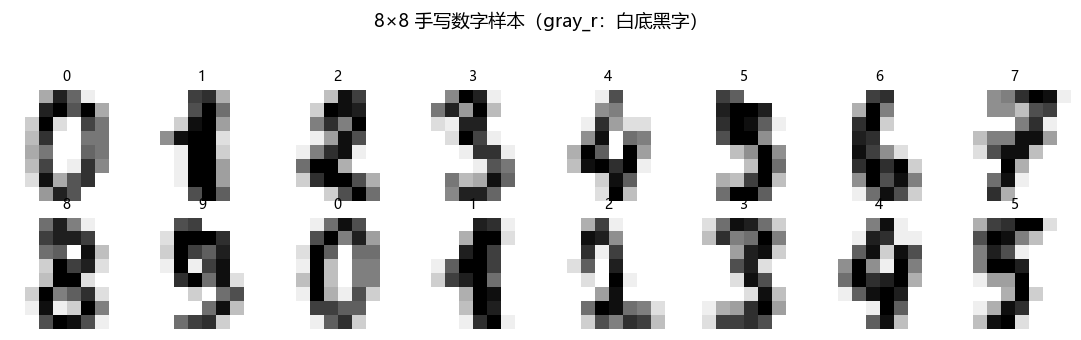

In [17]:
from sklearn.datasets import load_digits

digits = load_digits()
Xd_img = digits.images        # (1797, 8, 8) 原始图片
Xd = digits.data              # (1797, 64)   展平后的特征向量
td = digits.target            # 标签 0~9
print('图片数量:', Xd_img.shape[0], '，每张大小:', Xd_img.shape[1:], '，特征维度:', Xd.shape[1])

fig, axes = plt.subplots(2, 8, figsize=(10, 2.9), dpi=110)
for i, ax in enumerate(axes.ravel()):
    ax.imshow(Xd_img[i], cmap='gray_r')
    ax.set_title(str(td[i]), fontsize=9); ax.axis('off')
plt.suptitle('8×8 手写数字样本（gray_r：白底黑字）', y=1.05)
plt.tight_layout(); plt.show()

In [18]:
# 预处理：像素值 0~16 → 缩放到 [0,1]（数值稳定，梯度下降更好收敛）
Xd = Xd / 16.0

# 打乱后划分训练集 / 测试集（前 1500 张训练，其余测试；更严谨的做法是交叉验证）
rng = np.random.default_rng(0)
idx = rng.permutation(len(td))
Xd, td = Xd[idx], td[idx]
n_tr = 1500
Xd_tr, td_tr = Xd[:n_tr], td[:n_tr]
Xd_te, td_te = Xd[n_tr:], td[n_tr:]
Yd_tr = one_hot(td_tr, 10)      # 标签 → one-hot（复用前面定义的 one_hot）
print('训练集:', Xd_tr.shape, '  测试集:', Xd_te.shape)

训练集: (1500, 64)   测试集: (297, 64)


训练完成：最后一轮训练损失 = 0.075


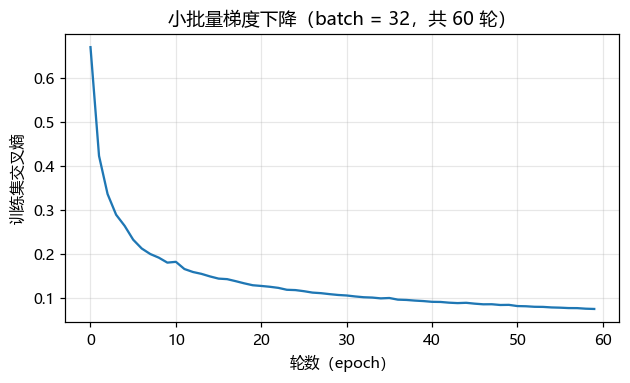

In [19]:
def train_softmax_minibatch(X, Y, epochs=60, batch_size=32, eta=0.5, seed=0):
    # 小批量梯度下降：每轮把训练集打乱、按 32 张一小批更新（速度和稳定性兼顾）
    rng_ = np.random.default_rng(seed)
    N, D = X.shape
    Xb = np.column_stack([X, np.ones(N)])            # 加偏置列
    W = np.zeros((D + 1, Y.shape[1]))
    hist = []
    for ep in range(epochs):
        order = rng_.permutation(N)
        for s in range(0, N, batch_size):
            b = order[s:s + batch_size]
            P = softmax_rows(Xb[b] @ W)
            W -= eta * (Xb[b].T @ (P - Y[b])) / len(b)   # 梯度 = 预测 − 真实
        P_all = softmax_rows(Xb @ W)                     # 每轮记录一次全量训练损失
        hist.append(float(-np.mean(np.sum(Y * np.log(P_all + 1e-12), axis=1))))
    return W, hist

W_digit, hist_digit = train_softmax_minibatch(Xd_tr, Yd_tr)
print('训练完成：最后一轮训练损失 =', round(hist_digit[-1], 4))

plt.figure(figsize=(6.5, 3.4), dpi=110)
plt.plot(hist_digit)
plt.xlabel('轮数（epoch）'); plt.ylabel('训练集交叉熵')
plt.title(f'小批量梯度下降（batch = 32，共 {len(hist_digit)} 轮）')
plt.grid(alpha=0.3); plt.show()

测试集准确率：98.0%（291 / 297 张判对）


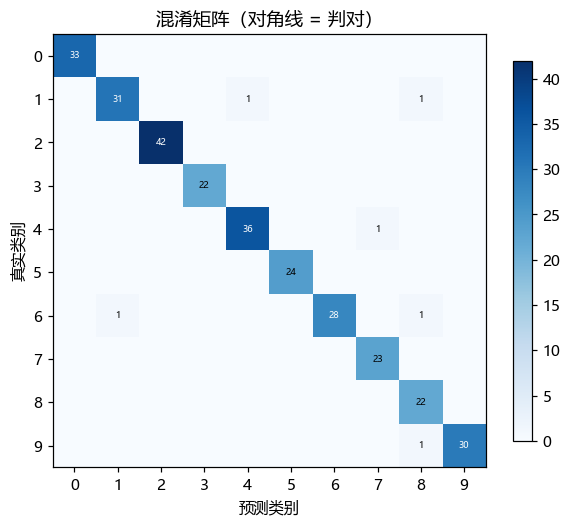

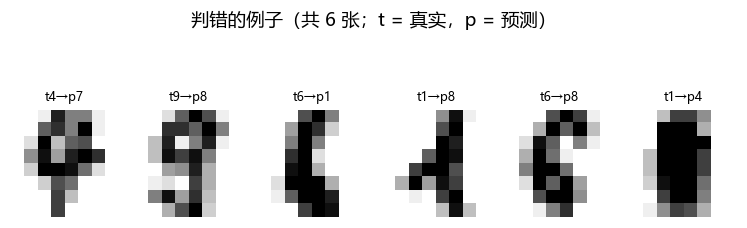

In [20]:
def predict_proba(Xnew, W):
    # 任意样本 → 10 个类别的概率
    Xb = np.column_stack([Xnew, np.ones(len(Xnew))])
    return softmax_rows(Xb @ W)

proba_te = predict_proba(Xd_te, W_digit)
pred_te = proba_te.argmax(1)
print(f'测试集准确率：{(pred_te == td_te).mean():.1%}（{int((pred_te == td_te).sum())} / {len(td_te)} 张判对）')

# 混淆矩阵：第 i 行 = 真实为 i 的图片，第 j 列 = 被预测成 j 的数量
Cm = np.zeros((10, 10), dtype=int)
for ti, pi in zip(td_te, pred_te):
    Cm[ti, pi] += 1

plt.figure(figsize=(5.6, 4.8), dpi=110)
plt.imshow(Cm, cmap='Blues')
plt.colorbar(shrink=0.85)
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel('预测类别'); plt.ylabel('真实类别'); plt.title('混淆矩阵（对角线 = 判对）')
for i in range(10):
    for j in range(10):
        if Cm[i, j]:
            plt.text(j, i, Cm[i, j], ha='center', va='center', fontsize=6,
                     color='white' if Cm[i, j] > 0.6 * Cm.max() else 'black')
plt.tight_layout(); plt.show()

# 看看判错的长什么样
wrong = np.where(pred_te != td_te)[0]
if len(wrong):
    k = min(10, len(wrong))
    fig, axes = plt.subplots(1, k, figsize=(1.15 * k, 1.8), dpi=110)
    for ax, i in zip(np.atleast_1d(axes), wrong[:k]):
        ax.imshow(Xd_te[i].reshape(8, 8), cmap='gray_r')
        ax.set_title(f't{td_te[i]}→p{pred_te[i]}', fontsize=8); ax.axis('off')
    plt.suptitle(f'判错的例子（共 {len(wrong)} 张；t = 真实，p = 预测）', y=1.18)
    plt.tight_layout(); plt.show()

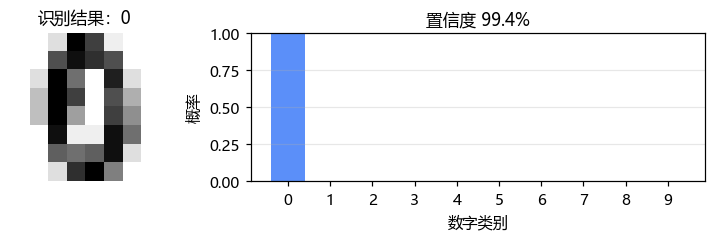

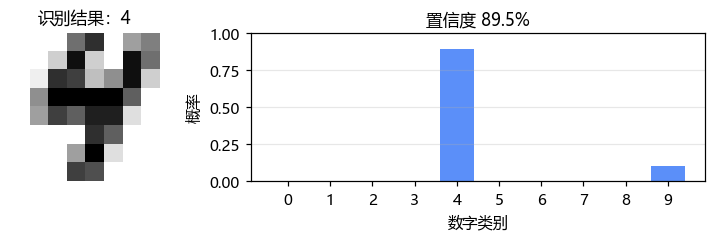

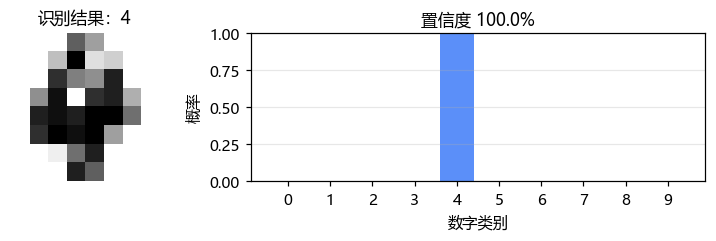

In [21]:
def recognize_digit(img, W=W_digit, show=True):
    # 手写数字识别：输入 8×8 灰度图（白底黑字、0~16）或 64 维向量 → 返回 (预测类别, 10 类概率)
    x = np.asarray(img, dtype=float).reshape(1, -1)
    if x.max() > 1.0:
        x = x / 16.0                       # 若还是 0~16 的原始像素，先缩放
    p = predict_proba(x, W)[0]
    pred = int(p.argmax())
    if show:
        fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.3), dpi=110,
                                 gridspec_kw={'width_ratios': [1, 2.4]})
        axes[0].imshow(x.reshape(8, 8), cmap='gray_r')
        axes[0].axis('off'); axes[0].set_title(f'识别结果：{pred}', fontsize=11)
        axes[1].bar(range(10), p, color='#5B8FF9')
        axes[1].set_xticks(range(10)); axes[1].set_ylim(0, 1)
        axes[1].set_xlabel('数字类别'); axes[1].set_ylabel('概率')
        axes[1].set_title(f'置信度 {p[pred]:.1%}', fontsize=11)
        axes[1].grid(alpha=0.3, axis='y')
        plt.tight_layout(); plt.show()
    return pred, p

# 拿几张没见过的测试图，试试这个"识别功能"
for i in [0, 1, 2]:
    recognize_digit(Xd_te[i])

外部 png 读入并识别（真实标签 0 ）：


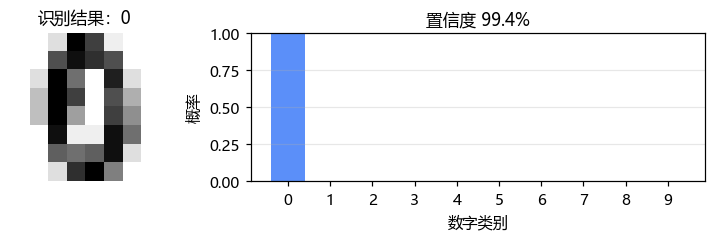

（还没有 my_digit.png —— 想试自己的字：白纸黑笔写大一点、笔画粗一点，拍照裁成方形存为 my_digit.png，放到本 notebook 同目录，再运行本 cell）


In [22]:
def load_digit_image(path):
    # 把任意尺寸的图片文件处理成和训练数据同规格的 8×8 图（白底黑字）
    img = plt.imread(path)
    if img.ndim == 3:                                    # 彩色 → 灰度
        img = img[..., :3] @ np.array([0.299, 0.587, 0.114])
    img = (1 - img) * 16                                 # 反转：黑字 → 大数值，白底 → 0
    h, w = img.shape
    iy = np.linspace(0, h - 1, 8).astype(int)            # 最近邻缩放成 8×8
    ix = np.linspace(0, w - 1, 8).astype(int)
    small = img[np.ix_(iy, ix)]
    return small / max(small.max(), 1e-9) * 16           # 对比度归一化

# ① 先自测这条"读外部图片"的通路：从测试集挑一张判对的图，存成 png 再读回来识别
import os, tempfile
i_ok = int(np.where(pred_te == td_te)[0][0])
f_demo = os.path.join(tempfile.gettempdir(), 'demo_digit.png')
plt.imsave(f_demo, Xd_te[i_ok].reshape(8, 8), cmap='gray_r')   # 像素已是 0~1，直接存
print('外部 png 读入并识别（真实标签', td_te[i_ok], '）：')
recognize_digit(load_digit_image(f_demo))

# ② 识别你自己的字：把"黑字白底"的图片存成 my_digit.png 放到本 notebook 同目录，再运行本 cell
if os.path.exists('my_digit.png'):
    pred, _ = recognize_digit(load_digit_image('my_digit.png'))
    print('my_digit.png 识别结果：', pred)
else:
    print('（还没有 my_digit.png —— 想试自己的字：白纸黑笔写大一点、笔画粗一点，拍照裁成方形存为 my_digit.png，'
          '放到本 notebook 同目录，再运行本 cell）')

**这一节做了什么**：图片 → 展平成 64 维向量 → 全连接层 $\boldsymbol z=\boldsymbol W\boldsymbol x+\boldsymbol b$ → Softmax → 取概率最大的类别。模型、损失、梯度全都是前面手推过的同一套 —— 这就是"图像分类"的最简完整流水线。

**想再进一步（选做）**：
- **换成真正的 MNIST**（28×28、6 万张训练图）：数据加载换成 `sklearn.datasets.fetch_openml('mnist_784')`，批次大小/轮数调大即可，代码结构完全一样；
- **提准确率**：给模型加一个隐藏层 + ReLU —— 这就进入下一讲"前馈神经网络"，损失函数与梯度形式都不用变；
- 本讲学过的技巧在这里全都用得上：**L2 正则化、标签平滑、调整学习率**（比如给损失加一项 $\lambda\|\boldsymbol W\|^2$，看泛化会不会更好）。